# Oracle Model — Accuracy-Oriented Random Forest

A high-accuracy Random Forest trained on all completed W&B runs to act as simulated ground truth for convergence simulation. Unlike the acquisition surrogate (which maximizes tree diversity for σ̂ signal), the oracle maximizes predictive accuracy.

**Final hyperparams:**

| Parameter | Value |
|-----------|-------|
| `n_estimators` | 512 |
| `max_features` | `None` (all features) |
| `max_samples` | `None` (full bootstrap) |
| `min_samples_leaf` | 3 |

In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from src.visualization import set_themes
from src.utils import get_kernel_id
from src.utils.config import parse_score_metric, Log10Transformer
from src.utils.styled_tables import data_preview_styled
from IPython.display import Markdown

from typing import List

set_themes()
pl.Config.set_tbl_rows(20)

polars.config.Config

## Configuration

Define the target metric and the discrete hyperparameter space to enumerate over.

In [2]:
run_summary_file = "wandb/summary.parquet"

# Target metric spec — same format as model_based_parse_parameters
# Single metric: "epoch/test_recall@20"
# Weighted composite: "epoch/test_recall@20:0.7 epoch/test_ndcg@20:0.3"
target_spec = "epoch/test_recall@20"
parsed_target = parse_score_metric(target_spec)
target_metric = "target"

# Hyperparameter columns to use as surrogate features.
# parameter_space (the list of discrete values per column) is derived automatically
# from completed runs in the Data Loading step below.
feature_names = [
    "embedding_dimension",
    "shuffle",
    "l1_regularization",
    "l2_regularization",
    "embedding_dropout_rate",
]

## Data Loading

Load completed runs from the local parquet cache produced by `wandb/sync.py`.

In [3]:
experiment_runs = pl.read_parquet(run_summary_file)
experiment_runs = experiment_runs.filter(pl.col("model") == "matrix_factorization")

# Compute target: best weighted composite score across epochs
# (same logic as model_based_parse_parameters in src/utils/config.py)
score_expression = sum(pl.col(m) * w for m, w in parsed_target.items())
experiment_runs = experiment_runs.with_columns(
    score_expression.list.max().alias(target_metric)
)

# Derive parameter_space from unique observed values per feature column
parameter_space = {}
for col in feature_names:
    unique_vals = sorted(experiment_runs[col].drop_nulls().unique().to_list())
    parameter_space[col] = unique_vals

total_space_size = 1
for values in parameter_space.values():
    total_space_size *= len(values)

print(f"Loaded {len(experiment_runs):,} runs")
print(f"Total joint parameter space: {total_space_size:,} configurations")
for col, vals in parameter_space.items():
    print(f"  {col}: {vals}")

Loaded 3,410 runs
Total joint parameter space: 20,000 configurations
  embedding_dimension: [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
  shuffle: [False, True]
  l1_regularization: [0.0, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
  l2_regularization: [0.0, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
  embedding_dropout_rate: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


In [4]:
top_runs = (
    experiment_runs
    .sort(pl.col(target_metric), descending=True)
    .select(["run_id", "run_name", *feature_names, target_metric])
    .to_pandas()
)

data_preview_styled(
    top_runs,
    caption="Top runs by target score — best epoch test_recall@20 across all completed runs"
)

,run_id,run_name,embedding_dimension,shuffle,l1_regularization,l2_regularization,embedding_dropout_rate,target
0,kl4wqlfj,fallen-frost-6124,1024,False,1e-07,1e-07,0,0.0510807
1,06bqx7vi,spring-vortex-3451,512,False,1e-07,1e-07,0,0.0508812
2,ppnmplwp,light-vortex-4549,512,False,1e-07,1e-07,0,0.0508023
3,3f5jmpwt,crisp-sponge-5704,512,False,1e-07,1e-07,0,0.0508023
4,tc5m18b1,northern-wildflower-4878,512,False,1e-07,1e-07,0,0.0507871
5,th4pgbno,dark-elevator-3601,512,False,1e-07,1e-07,0,0.0507706
6,0287jiys,visionary-dust-4876,512,False,1e-07,1e-07,0,0.050766
7,xznge89i,zesty-mountain-5325,512,False,1e-07,1e-07,0,0.0507626
8,yir89nn4,eager-lake-6123,256,False,1e-07,1e-07,0,0.0507551
9,w1trw3q4,neat-field-5327,512,False,1e-07,1e-07,0,0.0507536


## Data Preparation

Extract X (hyperparameter features) and y (best checkpoint score) from the loaded runs. Rows with missing target values are dropped.

- `shuffle` is cast to float (True → 1.0, False → 0.0)
- `l1_regularization` and `l2_regularization` are kept in raw scale here. The **log₁₀ transform** is applied inside the sklearn `Pipeline` as the first step, so the raw values flow cleanly through all data preparation and grid enumeration steps.

In [5]:
# Keep only rows that have all feature columns and the target metric
required_cols = feature_names + [target_metric]
full_dataframe = experiment_runs.select(required_cols).drop_nulls()

# Cast shuffle (boolean) to float so sklearn is happy
full_dataframe = full_dataframe.with_columns(pl.col("shuffle").cast(pl.Float64))

full_features = full_dataframe.select(feature_names).to_numpy()
full_target = full_dataframe[target_metric].to_numpy()

print(f"Training samples: {len(full_target):,}")
print(f"Target range:  [{full_target.min():.4f}, {full_target.max():.4f}]")
print(f"Target mean:   {full_target.mean():.4f}  ±  {full_target.std():.4f}")

Training samples: 3,410
Target range:  [0.0004, 0.0511]
Target mean:   0.0217  ±  0.0193


### Run Density per Parameter Region

Before choosing a leave-one-region-out holdout, check how many runs exist per value of each feature. A good holdout region should have:
- Enough runs to make the evaluation meaningful (≥ 10)
- Cover a range of target scores (not all zeros or all best)
- Not be at the extreme of the space (otherwise the surrogate has no neighbours to generalise from)

In [6]:
# Run density per parameter region — count, mean, std, min, max of target score
from src.utils.styled_tables import data_preview_styled
from IPython.display import display

for col in feature_names:
    summary = (
        full_dataframe
        .group_by(col)
        .agg(
            pl.len().alias("n_runs"),
            pl.col(target_metric).mean().alias("mean_score"),
            pl.col(target_metric).std().alias("std_score"),
            pl.col(target_metric).min().alias("min_score"),
            pl.col(target_metric).max().alias("max_score"),
        )
        .sort(col)
    )
    display(data_preview_styled(
        summary.to_pandas(),
        caption=f"Run density — {col}"
    ))

,embedding_dimension,n_runs,mean_score,std_score,min_score,max_score
0,2,338,0.013443,0.0118992,0.000425755,0.0292629
1,4,293,0.0200285,0.0158695,0.000413417,0.0374408
2,8,276,0.0235321,0.0184333,0.000449044,0.0434386
3,16,261,0.0229431,0.0195534,0.000412689,0.0472051
4,32,273,0.0232647,0.0201828,0.000411988,0.0490338
5,64,361,0.0234604,0.0205648,0.000410302,0.0497937
6,128,487,0.0226751,0.0207202,0.000437045,0.0507021
7,256,363,0.0233303,0.0203385,0.000415255,0.0507551
8,512,348,0.0223596,0.0201198,0.000419744,0.0508812
9,1024,410,0.0222227,0.0200036,0.000398079,0.0510807


,shuffle,n_runs,mean_score,std_score,min_score,max_score
0,0,2272,0.0214743,0.0197549,0.000398079,0.0510807
1,1,1138,0.0222585,0.0183199,0.000410302,0.0500979


,l1_regularization,n_runs,mean_score,std_score,min_score,max_score
0,0,1320,0.028931,0.0160959,0.00053644,0.0494515
1,1e-10,62,0.038684,0.00441301,0.0247856,0.0429082
2,1e-09,329,0.0323038,0.0151901,0.00165781,0.049774
3,1e-08,313,0.0318416,0.015683,0.00163111,0.0501882
4,1e-07,347,0.0352187,0.0165576,0.000738772,0.0510807
5,1e-06,295,0.000828726,0.000143465,0.000398079,0.00146874
6,1e-05,306,0.000670791,0.000101764,0.000413417,0.000980718
7,0.0001,298,0.000594325,4.60195e-05,0.000508673,0.00075964
8,0.001,72,0.000634661,2.9106e-05,0.000571359,0.000725075
9,0.01,68,0.000655063,4.09864e-05,0.000600912,0.000841356


,l2_regularization,n_runs,mean_score,std_score,min_score,max_score
0,0,1345,0.0254883,0.0180393,0.000508673,0.0481629
1,1e-10,56,0.0384051,0.00491479,0.0236655,0.0431684
2,1e-09,294,0.0258825,0.0192037,0.000521569,0.0482935
3,1e-08,303,0.0266934,0.0192814,0.000521914,0.0483897
4,1e-07,337,0.0301132,0.0211946,0.000517333,0.0510807
5,1e-06,312,0.0262776,0.0202885,0.000539916,0.0457204
6,1e-05,309,0.00881289,0.00885273,0.000413417,0.0261704
7,0.0001,315,0.00244037,0.00174603,0.000398079,0.0081746
8,0.001,71,0.000664741,7.17899e-05,0.00053644,0.00082273
9,0.01,68,0.00152737,0.000407259,0.000760497,0.00239232


,embedding_dropout_rate,n_runs,mean_score,std_score,min_score,max_score
0,0,2575,0.0199577,0.0196509,0.000398079,0.0510807
1,0.1,60,0.0383361,0.00546677,0.0219445,0.0437118
2,0.2,58,0.0383097,0.00632784,0.0197022,0.0449339
3,0.3,60,0.0382748,0.00644093,0.0206895,0.0448783
4,0.4,360,0.0218636,0.0200383,0.000486882,0.0470823
5,0.5,63,0.0370134,0.00727223,0.0165025,0.0437209
6,0.6,60,0.034982,0.00756476,0.0171414,0.0431936
7,0.7,58,0.0324964,0.00731701,0.0156488,0.0407066
8,0.8,58,0.0269155,0.00681717,0.011032,0.0352224
9,0.9,58,0.00279929,0.00084473,0.00194933,0.00576348


## Oracle Model Training

Fit a **Random Forest Regressor** with accuracy-oriented hyperparams. The oracle serves as simulated ground truth for convergence simulation.

- `max_features=None` — each tree sees all features (no feature subsampling)
- `max_samples=None` — full bootstrap (default, each tree sees ~63% of samples)
- `n_estimators=512` — enough trees for stable predictions
- `min_samples_leaf=1` — deep trees for maximum accuracy

`oob_score=True` gives an out-of-bag R² estimate without needing a held-out split.

In [15]:
# Oracle: accuracy-oriented RF (no diversity tricks)
oracle = Pipeline([
    ("log_reg", Log10Transformer(feature_names)),
    ("rf", RandomForestRegressor(
        n_estimators=512,
        max_features=None,
        max_samples=None,
        min_samples_leaf=3,
        oob_score=True,
        n_jobs=-1,
        random_state=42,
    )),
])

oracle.fit(full_features, full_target)
print(f"OOB R²: {oracle.named_steps['rf'].oob_score_:.4f}")

OOB R²: 0.9989


## Hyperparameter Tuning

Try different combinations to maximize cliff holdout performance. The current oracle (`max_features=None`) scores 0.9136 R² on the cliff — worse than the acquisition model (0.9232 with `max_features="sqrt"`), suggesting full feature access overfits the cliff boundary.

## Model Evaluation — Leave-Cliff-Out

Hold out runs at or across the two performance cliffs (l1=1e-6/1e-7, l2=1e-5/1e-6). This forces the oracle to extrapolate across the performance discontinuities — the hardest test of predictive accuracy.

In [16]:
# Test set: runs at or across either performance cliff
mask_cliff = (
    full_dataframe["l1_regularization"].is_in([1e-7, 1e-6])
    | full_dataframe["l2_regularization"].is_in([1e-6, 1e-5])
)

train_dataframe = full_dataframe.filter(~mask_cliff)
test_dataframe  = full_dataframe.filter(mask_cliff)

train_features = train_dataframe.select(feature_names).to_numpy()
train_target   = train_dataframe[target_metric].to_numpy()
test_features  = test_dataframe.select(feature_names).to_numpy()
test_target    = test_dataframe[target_metric].to_numpy()

print(f"Train size: {len(train_dataframe):,}  |  Test size (cliff runs): {len(test_dataframe):,}")
print(f"Test target range: [{test_target.min():.4f}, {test_target.max():.4f}]")
print()

oracle_eval = Pipeline([
    ("log_reg", Log10Transformer(feature_names)),
    ("rf", RandomForestRegressor(
        n_estimators=512,
        max_features=None,
        max_samples=None,
        min_samples_leaf=3,
        oob_score=False,
        n_jobs=-1,
        random_state=42,
    )),
])
oracle_eval.fit(train_features, train_target)
predicted_target = oracle_eval.predict(test_features)

print(f"Held-out R²  : {r2_score(test_target, predicted_target):.4f}")
print(f"Held-out MAE : {mean_absolute_error(test_target, predicted_target):.4f}")
 
# Rank-based metrics — the simulation only needs correct ordering
from scipy.stats import spearmanr

spearman_rho, _ = spearmanr(test_target, predicted_target)
print(f"Spearman ρ   : {spearman_rho:.4f}")

for k in [50, 100, 200]:
    ideal_order = np.argsort(-test_target)[:k]
    ideal_dcg = sum(
        (2 ** test_target[i] - 1) / np.log2(j + 2) for j, i in enumerate(ideal_order)
    )
    pred_order = np.argsort(-predicted_target)[:k]
    dcg = sum(
        (2 ** test_target[i] - 1) / np.log2(j + 2) for j, i in enumerate(pred_order)
    )
    ndcg = dcg / ideal_dcg if ideal_dcg > 0 else 0.0
    print(f"NDCG@{k:<8d}: {ndcg:.4f}")

Train size: 2,301  |  Test size (cliff runs): 1,109
Test target range: [0.0004, 0.0511]

Held-out R²  : 0.9136
Held-out MAE : 0.0029
Spearman ρ   : 0.9473
NDCG@50      : 0.9289
NDCG@100     : 0.9386
NDCG@200     : 0.9704


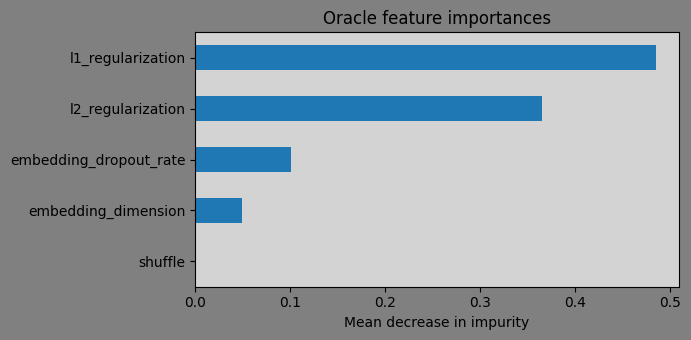

In [17]:
# Feature importance plot
fig, ax = plt.subplots(figsize=(7, 3.5))
importances = pd.Series(
    oracle_eval.named_steps["rf"].feature_importances_, index=feature_names
).sort_values(ascending=True)
importances.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Oracle feature importances")
plt.tight_layout()
plt.show()

### Hyperparameter Sweep Results

Full comparison of `max_features`, `max_samples`, and `min_samples_leaf` combinations on the cliff holdout. The chosen config (`all-feat, leaf=3`) balances highest Spearman ρ with strong R².

In [ ]:
from scipy.stats import spearmanr
from tqdm import tqdm

candidates = [
    {"max_features": "sqrt", "max_samples": None, "min_samples_leaf": 1, "config": "None, leaf=1"},
    {"max_features": "sqrt", "max_samples": None, "min_samples_leaf": 2, "config": "None, leaf=2"},
    {"max_features": "sqrt", "max_samples": None, "min_samples_leaf": 3, "config": "None, leaf=3"},
    {"max_features": "sqrt", "max_samples": None, "min_samples_leaf": 5, "config": "None, leaf=5"},
    {"max_features": "sqrt", "max_samples": None, "min_samples_leaf": 10, "config": "None, leaf=10"},
    {"max_features": "sqrt", "max_samples": 0.1, "min_samples_leaf": 1, "config": "0.1, leaf=1"},
    {"max_features": "sqrt", "max_samples": 0.1, "min_samples_leaf": 2, "config": "0.1, leaf=2"},
    {"max_features": "sqrt", "max_samples": 0.1, "min_samples_leaf": 3, "config": "0.1, leaf=3"},
    {"max_features": "sqrt", "max_samples": 0.1, "min_samples_leaf": 5, "config": "0.1, leaf=5"},
    {"max_features": "sqrt", "max_samples": 0.1, "min_samples_leaf": 10, "config": "0.1, leaf=10"},
    {"max_features": "sqrt", "max_samples": 0.3, "min_samples_leaf": 1, "config": "0.3, leaf=1"},
    {"max_features": "sqrt", "max_samples": 0.3, "min_samples_leaf": 2, "config": "0.3, leaf=2"},
    {"max_features": "sqrt", "max_samples": 0.3, "min_samples_leaf": 3, "config": "0.3, leaf=3"},
    {"max_features": "sqrt", "max_samples": 0.3, "min_samples_leaf": 5, "config": "0.3, leaf=5"},
    {"max_features": "sqrt", "max_samples": 0.3, "min_samples_leaf": 10, "config": "0.3, leaf=10"},
    {"max_features": None, "max_samples": None, "min_samples_leaf": 1, "config": "all-feat, leaf=1"},
    {"max_features": None, "max_samples": None, "min_samples_leaf": 2, "config": "all-feat, leaf=2"},
    {"max_features": None, "max_samples": None, "min_samples_leaf": 3, "config": "all-feat, leaf=3"},
    {"max_features": None, "max_samples": None, "min_samples_leaf": 5, "config": "all-feat, leaf=5"},
    {"max_features": None, "max_samples": None, "min_samples_leaf": 10, "config": "all-feat, leaf=10"},
]

results = []
for params in tqdm(candidates, desc="Evaluating oracle hyperparams"):
    pipe = Pipeline([
        ("log_reg", Log10Transformer(feature_names)),
        ("rf", RandomForestRegressor(
            n_estimators=512,
            max_features=params["max_features"],
            max_samples=params["max_samples"],
            min_samples_leaf=params["min_samples_leaf"],
            oob_score=False, n_jobs=-1, random_state=42,
        )),
    ])
    pipe.fit(train_features, train_target)
    predictions = pipe.predict(test_features)

    r2 = r2_score(test_target, predictions)
    mae = mean_absolute_error(test_target, predictions)
    rho, _ = spearmanr(test_target, predictions)

    results.append({"config": params["config"], "R2": round(r2, 4), "MAE": round(mae, 6), "Spearman": round(rho, 4)})

comparison_table = pd.DataFrame(results)
data_preview_styled(
    comparison_table.set_index("config"),
    caption="Hyperparameter comparison on cliff holdout (full sweep)",
    max_rows=25,
)

Evaluating oracle hyperparams:   0%|                                                                                                                                   | 0/20 [00:00<?, ?it/s]

Evaluating oracle hyperparams: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:15<00:00,  1.31it/s]


,R2,MAE,Spearman
config,,,
"None, leaf=1",0.9144,0.00292,0.9446
"None, leaf=2",0.9157,0.002887,0.9399
"None, leaf=3",0.9163,0.002875,0.9337
"None, leaf=5",0.9188,0.002844,0.9226
"None, leaf=10",0.9191,0.002873,0.9197
"0.1, leaf=1",0.9236,0.002978,0.9367
"0.1, leaf=2",0.9216,0.003098,0.9248
"0.1, leaf=3",0.921,0.003298,0.9226
"0.1, leaf=5",0.9166,0.003827,0.9174


## Oracle Uncertainty — σ̂ Validation

The oracle should have low uncertainty (tight σ̂) everywhere the grid has been explored, confirming it's confident where it has training data. Unlike the acquisition surrogate (which maximizes σ̂ separation for exploration), the oracle's σ̂ should be uniformly tight — this validates that adding noise as ε ~ N(0, oracle_σ̂) in the simulation won't inject excessive variance.

Explored cells:   μ̂ = 0.019588 ± 0.019369   σ̂ = 0.000284 ± 0.000366
Unexplored cells: μ̂ = 0.010798 ± 0.016153   σ̂ = 0.000310 ± 0.000569
σ̂ ratio (unexplored / explored): 1.09x
Target: oracle σ̂ should be tight (ratio < 3x, unlike acquisition's target of > 1.5x for exploration)


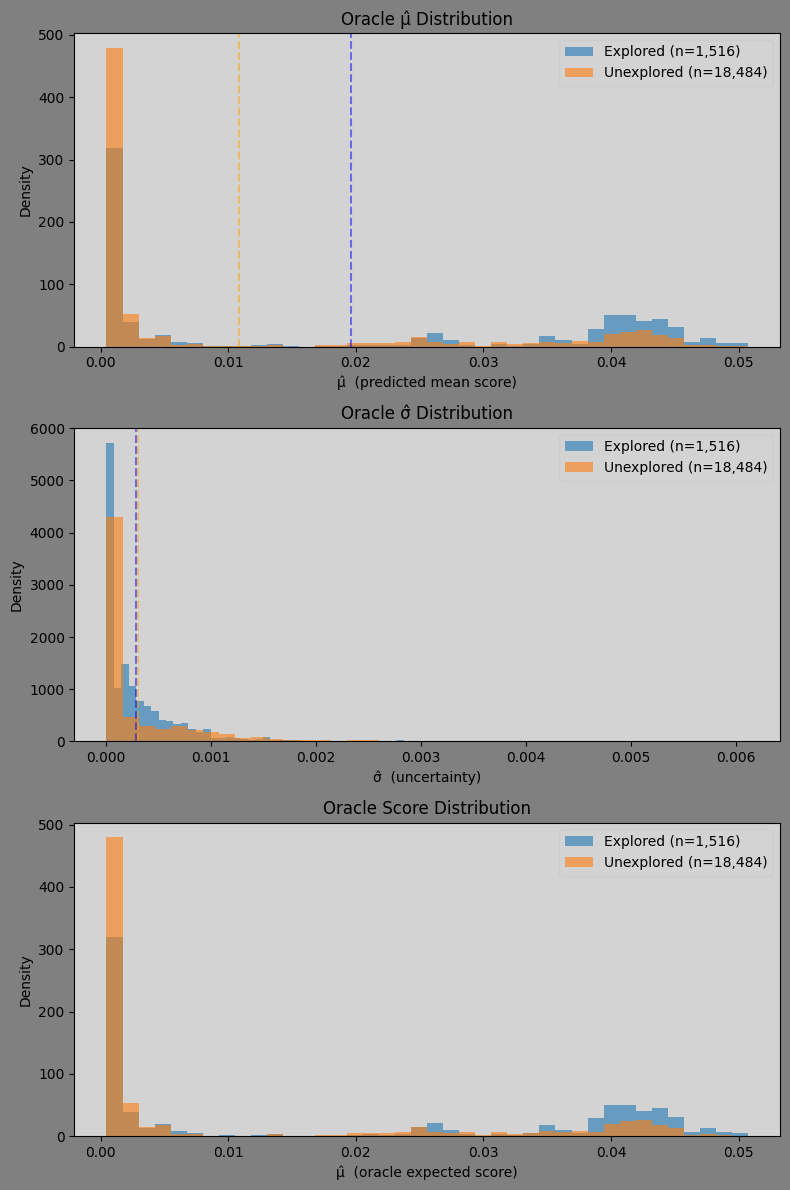

In [18]:
# Build full grid and compute oracle μ̂ and σ̂
all_combinations = list(itertools.product(*parameter_space.values()))
full_grid = pl.DataFrame(
    {col: [row[i] for row in all_combinations] for i, col in enumerate(feature_names)}
)
full_grid = full_grid.with_columns(pl.col("shuffle").cast(pl.Float64))

# Tag explored cells
explored_dataframe = (
    full_dataframe
    .group_by(feature_names)
    .agg(pl.col(target_metric).mean().alias(f"observed_{target_metric}"))
)
explored_keys = set(
    tuple(row) for row in explored_dataframe.select(feature_names).to_numpy().tolist()
)
full_grid = full_grid.with_columns(
    pl.struct(feature_names)
    .map_elements(lambda s: tuple(s[c] for c in feature_names) in explored_keys, return_dtype=pl.Boolean)
    .alias("explored")
)

# Predict μ̂ and σ̂ using the full-data oracle
grid_features = full_grid.select(feature_names).to_numpy()
oracle_rf = oracle.named_steps["rf"]
grid_features_log = oracle.named_steps["log_reg"].transform(grid_features)
tree_preds = np.stack([tree.predict(grid_features_log) for tree in oracle_rf.estimators_], axis=0)
mu_hat = tree_preds.mean(axis=0)
sigma_hat = tree_preds.std(axis=0)

full_grid = full_grid.with_columns([
    pl.Series("mu_hat", mu_hat),
    pl.Series("sigma_hat", sigma_hat),
])

explored_sigma = full_grid.filter(pl.col("explored"))["sigma_hat"].to_numpy()
unexplored_sigma = full_grid.filter(~pl.col("explored"))["sigma_hat"].to_numpy()
explored_mu = full_grid.filter(pl.col("explored"))["mu_hat"].to_numpy()
unexplored_mu = full_grid.filter(~pl.col("explored"))["mu_hat"].to_numpy()

sigma_ratio = unexplored_sigma.mean() / explored_sigma.mean()
print(f"Explored cells:   μ̂ = {explored_mu.mean():.6f} ± {explored_mu.std():.6f}   σ̂ = {explored_sigma.mean():.6f} ± {explored_sigma.std():.6f}")
print(f"Unexplored cells: μ̂ = {unexplored_mu.mean():.6f} ± {unexplored_mu.std():.6f}   σ̂ = {unexplored_sigma.mean():.6f} ± {unexplored_sigma.std():.6f}")
print(f"σ̂ ratio (unexplored / explored): {sigma_ratio:.2f}x")
print(f"Target: oracle σ̂ should be tight (ratio < 3x, unlike acquisition's target of > 1.5x for exploration)")

# Histogram comparison — μ̂, σ̂, and UCB side by side
axes: List[plt.Axes]
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# μ̂ distribution
axes[0].hist(explored_mu, bins=40, alpha=0.6, density=True, label=f"Explored (n={len(explored_mu):,})")
axes[0].hist(unexplored_mu, bins=40, alpha=0.6, density=True, label=f"Unexplored (n={len(unexplored_mu):,})")
axes[0].axvline(explored_mu.mean(), color='blue', linestyle='--', alpha=0.5)
axes[0].axvline(unexplored_mu.mean(), color='orange', linestyle='--', alpha=0.5)
axes[0].set_xlabel("μ̂  (predicted mean score)")
axes[0].set_ylabel("Density")
axes[0].set_title("Oracle μ̂ Distribution")
axes[0].legend()

# σ̂ distribution
axes[1].hist(explored_sigma, bins=40, alpha=0.6, density=True, label=f"Explored (n={len(explored_sigma):,})")
axes[1].hist(unexplored_sigma, bins=40, alpha=0.6, density=True, label=f"Unexplored (n={len(unexplored_sigma):,})")
axes[1].axvline(explored_sigma.mean(), color='blue', linestyle='--', alpha=0.5)
axes[1].axvline(unexplored_sigma.mean(), color='orange', linestyle='--', alpha=0.5)
axes[1].set_xlabel("σ̂  (uncertainty)")
axes[1].set_ylabel("Density")
axes[1].set_title("Oracle σ̂ Distribution")
axes[1].legend()

# UCB distribution
axes[2].hist(explored_mu, bins=40, alpha=0.6, density=True, label=f"Explored (n={len(explored_mu):,})")
axes[2].hist(unexplored_mu, bins=40, alpha=0.6, density=True, label=f"Unexplored (n={len(unexplored_mu):,})")
axes[2].set_xlabel("μ̂  (oracle expected score)")
axes[2].set_ylabel("Density")
axes[2].set_title("Oracle Score Distribution")
axes[2].legend()

plt.tight_layout()
plt.show()